In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/insurance.csv")
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.region.unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [8]:
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy

,age,bmi,children,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [12]:
target = "charges"
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [13]:
X

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [9]:
from sklearn import model_selection

In [14]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3) # random split

In [15]:
len(X_train)/ len(X)

0.6995515695067265

In [16]:
len(X_test)/ len(X)

0.3004484304932735

In [17]:
import numpy as np

In [33]:
np.random.randint(0, 10, 3)

array([0, 6, 9])

In [44]:
np.random.seed(42342342) # seed any arbitrary int value
np.random.randint(0, 10, 3)

array([0, 8, 5])

In [62]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split
print(X_train)

      age     bmi  children  gender_male  smoker_yes  region_northwest  \
874    44  21.850         3         True       False             False   
179    41  33.155         3        False       False             False   
803    18  42.240         0        False        True             False   
806    40  41.420         1        False       False              True   
1207   36  33.400         2         True        True             False   
...   ...     ...       ...          ...         ...               ...   
1129   19  18.600         0        False       False             False   
697    41  35.750         1         True        True             False   
139    22  36.000         0        False       False             False   
1040   35  28.025         0        False        True              True   
1097   22  33.770         0         True       False             False   

      region_southeast  region_southwest  
874              False             False  
179              False   

In [63]:
from sklearn.linear_model import LinearRegression

In [65]:
est = LinearRegression()
est.fit(X_train, y_train) # learning process

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 253.01, 326.68, 562.96,..., -110.68, -676.96,-1336.46]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.143e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [66]:
y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

In [68]:
a = pd.DataFrame({"y": y_train, "y_pred": y_train_pred})
a["error"] = y_train-y_train_pred
a

,y,y_pred,error
874,8891.13950,8126.073280,765.066220
179,8538.28845,11460.934695,-2922.646245
803,38792.68560,30219.507359,8573.178241
806,28476.73499,12671.338036,15805.396954
1207,38415.47400,31951.544763,6463.929237
...,...,...,...
1129,1728.89700,-1885.539941,3614.436941
697,40273.64550,34080.844992,6192.800508
139,2166.73200,4557.749587,-2391.017587
1040,20234.85475,30443.249992,-10208.395242


<Axes: xlabel='y', ylabel='error'>

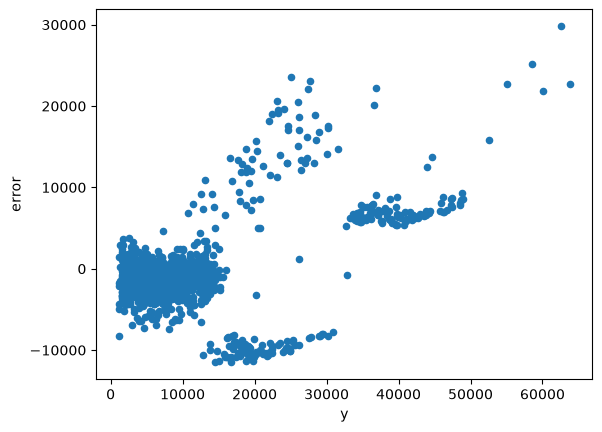

In [69]:
a.plot.scatter("y", "error")

<Axes: ylabel='Frequency'>

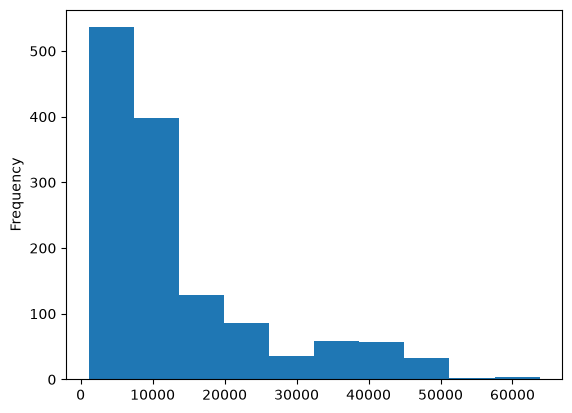

In [70]:
y.plot.hist()

In [74]:
est.intercept_ # intercepts 

np.float64(-11432.606373731733)

In [73]:
est.coef_ # coefficients

array([  253.01353098,   326.68097331,   562.95954273,  -400.77360467,
       23975.83079198,  -110.6822871 ,  -676.96492986, -1336.45675993])

In [75]:
X.columns

Index(['age', 'bmi', 'children', 'gender_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

In [82]:
str(est.intercept_) + " + "+  str([f"{r[0]} x {r[1]}" for r in zip(X.columns, est.coef_)])

"-11432.606373731733 + ['age x 253.01353098225488', 'bmi x 326.680973307241', 'children x 562.959542733436', 'gender_male x -400.7736046675539', 'smoker_yes x 23975.83079198142', 'region_northwest x -110.6822871005152', 'region_southeast x -676.9649298633199', 'region_southwest x -1336.4567599326688']"

In [84]:
pd.DataFrame({"feature": X.columns, "cofficient": est.coef_})

,feature,cofficient
0,age,253.013531
1,bmi,326.680973
2,children,562.959543
3,gender_male,-400.773605
4,smoker_yes,23975.830792
5,region_northwest,-110.682287
6,region_southeast,-676.964930
7,region_southwest,-1336.456760


```
y_hat = -11432.606373731733 + 253.013531 age + 326.680973 * bmi + ...
```

In [85]:
a = pd.DataFrame({"y": y_test, "y_pred": y_test_pred})
a["error"] = a['y'] - a['y_pred']
a

,y,y_pred,error
1096,44641.19740,37993.600411,6647.596989
532,12925.88600,13245.797412,-319.911412
703,5385.33790,6249.775440,-864.437540
1121,8347.16430,12723.609354,-4376.445054
513,1256.29900,1568.521939,-312.222939
...,...,...,...
692,2362.22905,4261.998027,-1899.768977
984,4915.05985,5879.685866,-964.626016
665,42560.43040,35904.464645,6655.965755
814,5584.30570,8971.687204,-3387.381504


In [88]:
x = np.array([4, 3, 2, 5, 2])
(x ** 2).sum()

np.int64(58)

In [89]:
sse = (a["error"] ** 2).sum() # sum of squared error 
sse

np.float64(15033636301.640009)

In [90]:
mse = (a["error"] ** 2).mean() # mean squared error 
mse

np.float64(37397105.22796022)

In [91]:
rmse = (a["error"] ** 2).mean() ** 0.5 # root mean squared error 
rmse

np.float64(6115.317263066588)

In [92]:
baseline_prediction = y_train.mean()
baseline_prediction

np.float64(13128.827082456197)

In [94]:
sst = ((y_test -baseline_prediction)**2).sum() # sum of squared total
sst 

np.float64(62057137018.758484)

In [95]:
sse/sst

np.float64(0.24225475140910346)

In [96]:
r2 = 1 - sse/sst, # r2 < 1 1
r2

np.float64(0.7577452485908965)

In [97]:
from sklearn import metrics

In [98]:
metrics.r2_score(y_test, y_test_pred)

0.7573961975013654

In [99]:
metrics.mean_squared_error(y_test, y_test_pred)

37397105.22796022

In [100]:
metrics.mean_squared_error(y_test, y_test_pred) ** 0.5 #rmse

6115.317263066588

In [103]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split
est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("test r2", metrics.r2_score(y_test, y_test_pred))

test r2 0.7573961975013654


In [104]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

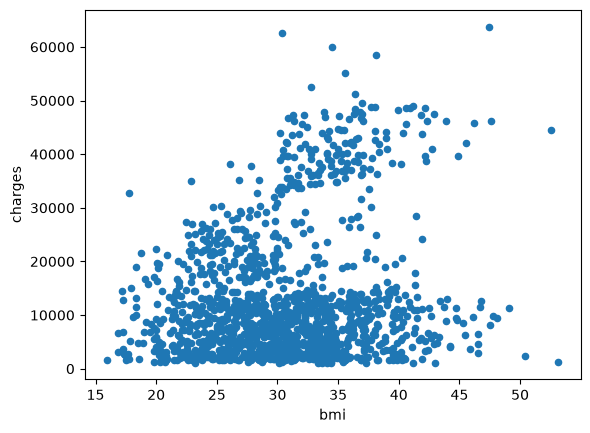

In [105]:
df.plot.scatter("bmi", "charges")

In [109]:
import matplotlib.pyplot as plt

<Axes: xlabel='bmi', ylabel='charges'>

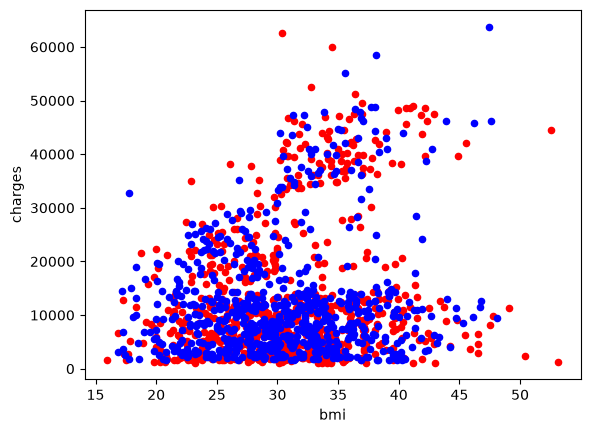

In [110]:
fig, ax = plt.subplots(1, 1)
df[df.gender == 'male'].plot.scatter("bmi", "charges", color ='red', ax = ax)
df[df.gender == 'female'].plot.scatter("bmi", "charges", color ='blue', ax = ax)

<Axes: xlabel='bmi', ylabel='charges'>

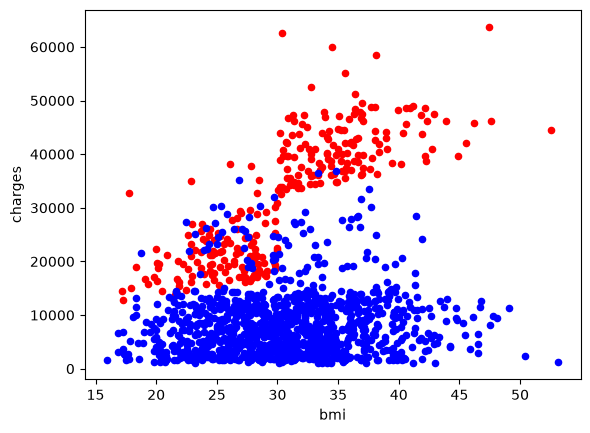

In [111]:
fig, ax = plt.subplots(1, 1)
df[df.smoker == 'yes'].plot.scatter("bmi", "charges", color ='red', ax = ax)
df[df.smoker == 'no'].plot.scatter("bmi", "charges", color ='blue', ax = ax)

In [112]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split
est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("test r2", metrics.r2_score(y_test, y_test_pred))

test r2 0.7578554383007432


In [113]:
a = np.random.randint(0, 5, (4, 3))
a

array([[1, 3, 2],
       [4, 3, 1],
       [4, 2, 0],
       [3, 3, 4]])

In [114]:
from sklearn.preprocessing import PolynomialFeatures

In [115]:
poly = PolynomialFeatures(degree=2)
b = poly.fit_transform(a)
b

array([[ 1.,  1.,  3.,  2.,  1.,  3.,  2.,  9.,  6.,  4.],
       [ 1.,  4.,  3.,  1., 16., 12.,  4.,  9.,  3.,  1.],
       [ 1.,  4.,  2.,  0., 16.,  8.,  0.,  4.,  0.,  0.],
       [ 1.,  3.,  3.,  4.,  9.,  9., 12.,  9., 12., 16.]])

```
              a    b    c    a^2  ab  ac    b^2 bc   c^2
-------------------------------------------------------------              
array([[ 1.,  1.,  3.,  2.,  1.,  3.,  2.,  9.,  6.,  4.],
       [ 1.,  4.,  3.,  1., 16., 12.,  4.,  9.,  3.,  1.],
       [ 1.,  4.,  2.,  0., 16.,  8.,  0.,  4.,  0.,  0.],
       [ 1.,  3.,  3.,  4.,  9.,  9., 12.,  9., 12., 16.]])
```

In [116]:
poly = PolynomialFeatures(degree=2, include_bias= False)
b = poly.fit_transform(a, )
b

array([[ 1.,  3.,  2.,  1.,  3.,  2.,  9.,  6.,  4.],
       [ 4.,  3.,  1., 16., 12.,  4.,  9.,  3.,  1.],
       [ 4.,  2.,  0., 16.,  8.,  0.,  4.,  0.,  0.],
       [ 3.,  3.,  4.,  9.,  9., 12.,  9., 12., 16.]])

In [120]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split

poly = preprocessing.PolynomialFeatures(degree=2, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

train r2 0.8446579625402135
test r2 0.8569340356442573


In [121]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split

poly = preprocessing.PolynomialFeatures(degree=3, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

train r2 0.8586914997835975
test r2 0.8341344885662637


In [124]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split

poly = preprocessing.PolynomialFeatures(degree=6, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

train r2 0.866729588810312
test r2 0.8105671636868631


<Axes: >

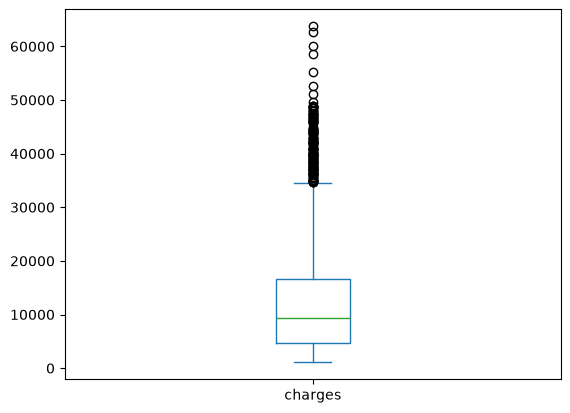

In [125]:
y.plot.box()

<Axes: >

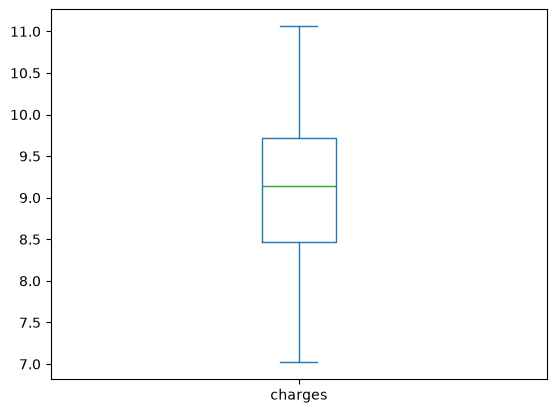

In [126]:
np.log(y).plot.box()

In [127]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split

# poly = preprocessing.PolynomialFeatures(degree=6, include_bias= False)
# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

train r2 0.7622296640477166
test r2 0.7787577360766283


In [128]:
a = np.random.randint(0, 5, (4, 3))
a

array([[2, 1, 4],
       [0, 0, 2],
       [0, 3, 1],
       [2, 1, 4]])

In [130]:
scaler = preprocessing.StandardScaler()
b = scaler.fit_transform(a)
b


array([[ 1.        , -0.22941573,  0.96225045],
       [-1.        , -1.14707867, -0.57735027],
       [-1.        ,  1.60591014, -1.34715063],
       [ 1.        , -0.22941573,  0.96225045]])

In [ ]:
# for every feature it calculates, z = (v - mean(v))/std(v)

# object: every feature should have 0 mean and 1 standard deviation

In [131]:
pd.DataFrame(b).describe()

,0,1,2
count,4.000000,4.000000e+00,4.000000
mean,0.000000,-4.163336e-17,0.000000
std,1.154701,1.154701e+00,1.154701
min,-1.000000,-1.147079e+00,-1.347151
25%,-1.000000,-4.588315e-01,-0.769800
50%,0.000000,-2.294157e-01,0.192450
75%,1.000000,2.294157e-01,0.962250
max,1.000000,1.605910e+00,0.962250


In [132]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# poly = preprocessing.PolynomialFeatures(degree=6, include_bias= False)
# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

train r2 0.7622296640477166
test r2 0.7787577360766283


train r2 0.8375201887962002
test r2 0.8524683559605071


Text(0.5, 1.0, 'Histogram of model weights')

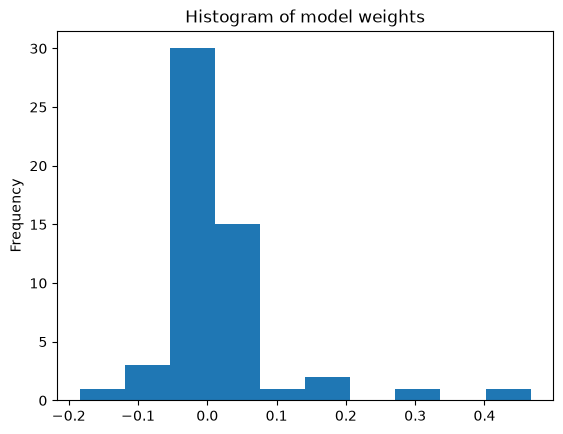

In [141]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

poly = preprocessing.PolynomialFeatures(degree=2, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

In [136]:
X_train.shape

(936, 5004)

train r2 0.8552854699956698
test r2 0.8389317742725316


Text(0.5, 1.0, 'Histogram of model weights')

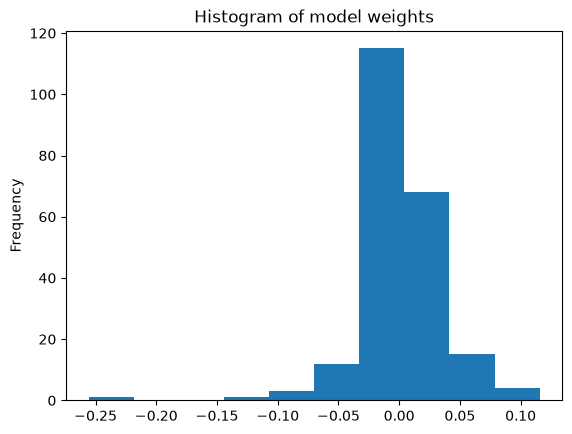

In [142]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

poly = preprocessing.PolynomialFeatures(degree=3, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

train r2 0.8838023219253475
test r2 0.7315235106490671


Text(0.5, 1.0, 'Histogram of model weights')

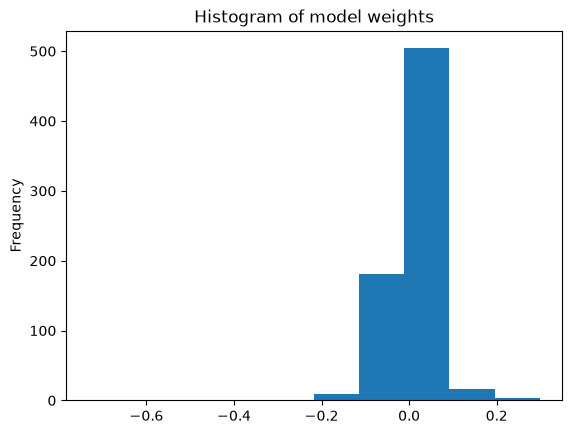

In [143]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

poly = preprocessing.PolynomialFeatures(degree=4, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

train r2 0.9310309666077352
test r2 -8791.610961359751


Text(0.5, 1.0, 'Histogram of model weights')

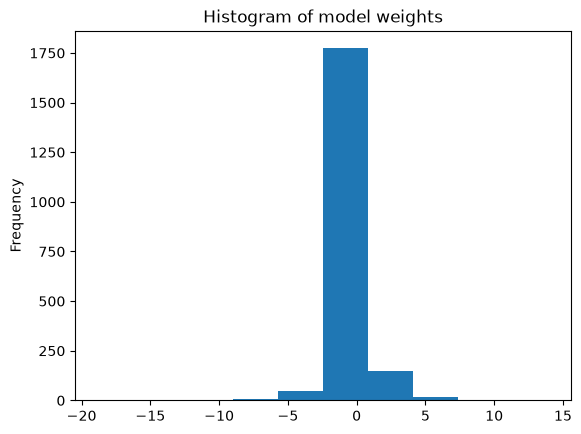

In [144]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

poly = preprocessing.PolynomialFeatures(degree=5, include_bias= False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

est = LinearRegression()  # Closed formed solution inv((t(X)X)t(X)y
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

In [145]:
pd.DataFrame({'y_test': y_test, 'y_test_pred': y_test_pred})

,y_test,y_test_pred
1096,10.706412,-57.437680
532,9.466987,10.496618
703,8.591435,8.682608
1121,9.029677,8.838429
513,7.135925,7.129356
...,...,...
692,7.767361,8.042519
984,8.500059,2.408142
665,10.658680,23.770641
814,8.627715,10.214044


train r2 0.7161445023000206
test r2 0.7317490802621043


Text(0.5, 1.0, 'Histogram of model weights')

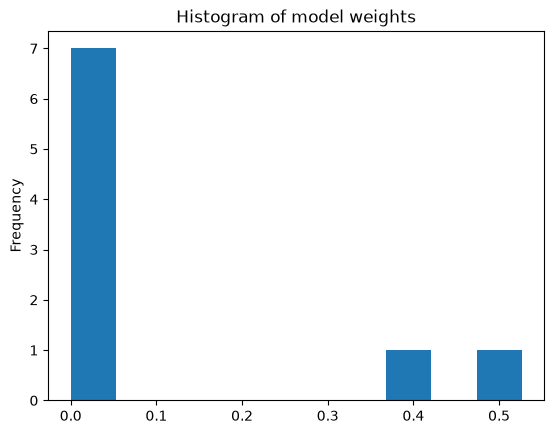

In [170]:
# LASSO model

from sklearn import model_selection
from sklearn.linear_model import Lasso, Ridge, ElasticNet, SGDRegressor # all of these gradient descent algo
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split

features = X_train.columns
# poly = preprocessing.PolynomialFeatures(degree=5, include_bias= False)
# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

est = Lasso(alpha=0.1) 
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

In [172]:
pd.DataFrame({"feature": features, "cef": est.coef_})

,feature,cef
0,age,0.387318
1,bmi,0.000000
2,children,0.023863
3,gender_male,-0.000000
4,smoker_yes,0.526352
5,region_northwest,0.000000
6,region_southeast,-0.000000
7,region_southwest,-0.000000
8,high_bmi,0.000000


train r2 0.7622296639489021
test r2 0.7787581573817253


Text(0.5, 1.0, 'Histogram of model weights')

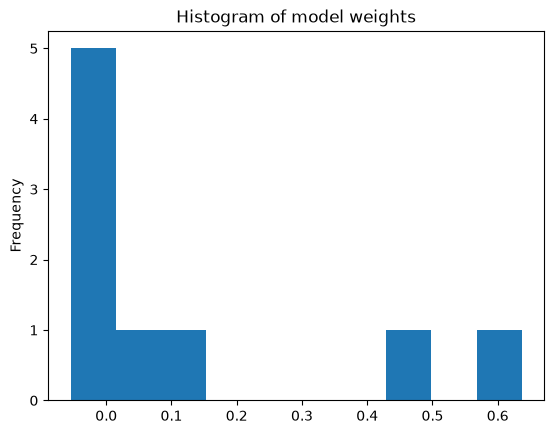

In [175]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import Lasso, Ridge, ElasticNet, SGDRegressor # all of these gradient descent algo
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# poly = preprocessing.PolynomialFeatures(degree=5, include_bias= False)
# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

est = Ridge(alpha=0.01)
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

train r2 0.7583445216101564
test r2 0.7898710951344445


Text(0.5, 1.0, 'Histogram of model weights')

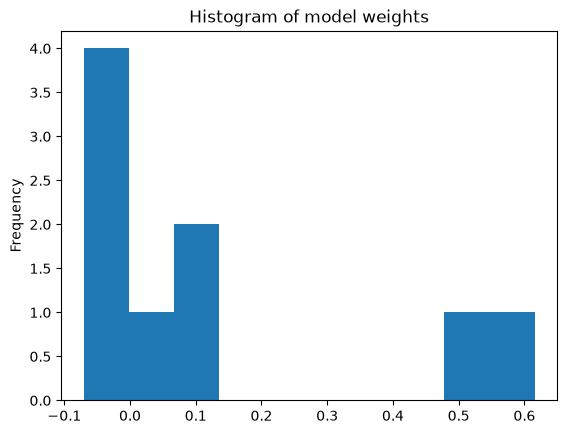

In [177]:
# control the outliers on the outcome variables by log transformation 

from sklearn import model_selection
from sklearn.linear_model import Lasso, Ridge, ElasticNet, SGDRegressor # all of these gradient descent algo
from sklearn import preprocessing

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=100) # random split


scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# poly = preprocessing.PolynomialFeatures(degree=5, include_bias= False)
# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

est = Ridge(alpha=0.01)
est.fit(X_train, y_train) # learning process

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

print("train r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

pd.Series(est.coef_).plot.hist()
plt.title("Histogram of model weights")

In [179]:
from sklearn import model_selection
from sklearn import pipeline

In [182]:

target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy["high_bmi"] = df["bmi"] > 33 # derived features
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)

pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', Ridge(alpha=0.01)),
])

scores = model_selection.cross_val_score(pipe, X, y, cv=5, scoring="r2")

np.mean(scores), np.std(scores)

(np.float64(0.7635270889876933), np.float64(0.05007503929877475))

In [183]:
pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', Lasso(alpha=0.01)),
])

scores = model_selection.cross_val_score(pipe, X, y, cv=5, scoring="r2")

np.mean(scores), np.std(scores)

(np.float64(0.7623969266806822), np.float64(0.04714689306403826))

In [185]:
pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', ElasticNet(alpha=0.01, l1_ratio=0.4)),
])
scores = model_selection.cross_val_score(pipe, X, y, cv=5, scoring="r2")
np.mean(scores), np.std(scores)

(np.float64(0.7633632381580444), np.float64(0.04824973448031171))

In [186]:
np.linspace(0.001, .999, 10)

array([0.001     , 0.11188889, 0.22277778, 0.33366667, 0.44455556,
       0.55544444, 0.66633333, 0.77722222, 0.88811111, 0.999     ])

In [189]:
2 ** np.linspace(-2, 0, 10)

array([0.25      , 0.29163226, 0.3401975 , 0.39685026, 0.46293736,
       0.54002987, 0.62996052, 0.73486725, 0.85724398, 1.        ])

In [191]:
%%time 

param_grid = {
    "est__l1_ratio": np.linspace(0.001, .999, 10),
    "est__alpha": 2 ** np.linspace(-2, 0, 10),
}


pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', ElasticNet(alpha=0.01, l1_ratio=0.4)),
])
scores = model_selection.cross_val_score(pipe, X, y, cv=5, scoring="r2")
np.mean(scores), np.std(scores)


target = "charges"
df_dummy = pd.get_dummies(df, drop_first=True)
y = np.log(df_dummy[target]) # label, target, outcome
X = df_dummy.drop(columns=target)


gsearch = model_selection.GridSearchCV(pipe, param_grid=param_grid, cv = 5)
gsearch.fit(X, y)

CPU times: user 2.58 s, sys: 196 μs, total: 2.58 s
Wall time: 2.58 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._ratio=0.4))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'est__alpha': array([0.25 ..., 1. ]), 'est__l1_ratio': array([0.001 ..., 0.999 ])}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

In [192]:
gsearch.best_params_

{'est__alpha': np.float64(0.25), 'est__l1_ratio': np.float64(0.001)}

In [193]:
import pickle

In [194]:
with open("mymodel.pickle", "wb") as f:
    pickle.dump(gsearch, f)

In [195]:
!ls -ls mymodel.pickle

16 -rw-rw-r-- 1 aio aio 16200 Sep 17 15:43 mymodel.pickle


In [196]:
with open("mymodel.pickle", "rb") as f:
    model_reloaded = pickle.load(f)
    print(model_reloaded)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('est',
                                        ElasticNet(alpha=0.01, l1_ratio=0.4))]),
             param_grid={'est__alpha': array([0.25      , 0.29163226, 0.3401975 , 0.39685026, 0.46293736,
       0.54002987, 0.62996052, 0.73486725, 0.85724398, 1.        ]),
                         'est__l1_ratio': array([0.001     , 0.11188889, 0.22277778, 0.33366667, 0.44455556,
       0.55544444, 0.66633333, 0.77722222, 0.88811111, 0.999     ])})
